# Phase 2 — Model Evaluation

This notebook focuses on evaluating the fine-tuned **Legal-BERT** model on the held-out test set. We analyze performance across various legal categories and provide metrics like Accuracy, F1-Score, and a Confusion Matrix.


In [1]:
pip install "torch>=2.4.0" "numpy<2.0.0" transformers pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations
import gc
import json
import os
import sys
from pathlib import Path

import torch
from transformers import AutoTokenizer

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase2.models.bert_classifier import BertWithLengthClassifier

PHASE2_DIR = PROJECT_ROOT / "phase2_results"
MODEL_NAME = "nlpaueb/legal-bert-base-uncased"

label_path = PHASE2_DIR / "label2id.json"
tok_path = PHASE2_DIR / "tokenizer"
w_path = PHASE2_DIR / "legal_bert_phase2.pt"

with open(label_path, encoding="utf-8") as f:
    label2id = json.load(f)
id2label = {int(v): k for k, v in label2id.items()}
num_classes = len(label2id)

tokenizer = AutoTokenizer.from_pretrained(str(tok_path))
model = BertWithLengthClassifier(MODEL_NAME, num_classes=num_classes, use_length_feature=True, download_pretrained_backbone=False)

state = torch.load(w_path, map_location="cpu")
if isinstance(state, dict) and "state_dict" in state: state = state["state_dict"]
model.load_state_dict(state, strict=False)
model.eval()
print(f"Model loaded with {num_classes} classes.")

/Users/divyanshisachan/Desktop/agastya/agastya_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded with 41 classes.


## Load Test Dataset


In [3]:
from torch.utils.data import DataLoader
from src.phase2.data.dataset import ContractDataset
from src.phase2.data.dataset_loader import load_processed_splits

DATA_DIR = PROJECT_ROOT / "data" / "processed"
_, _, test_df, _ = load_processed_splits(
    DATA_DIR / "train.csv", 
    DATA_DIR / "val.csv", 
    DATA_DIR / "test.csv", 
    label2id_path=label_path
)

test_dataset = ContractDataset(test_df, tokenizer, max_length=128)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)
print(f"Test set size: {len(test_df)}")

Test set size: 627


## Run Evaluation


In [6]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import tqdm

all_preds = []
all_labels = []

print("Evaluating...")
with torch.no_grad():
    for batch in tqdm.tqdm(test_loader):
        labels = batch.pop("label").numpy()
        logits = model(
            batch["input_ids"], 
            batch["attention_mask"], 
            length_feat=batch["length_feat"]
        )
        preds = torch.argmax(logits, dim=1).numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {acc:.4f}")

# Report
target_names = [id2label[i] for i in range(num_classes)]
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, labels=range(num_classes), target_names=target_names))


Evaluating...


100%|██████████| 157/157 [00:34<00:00,  4.50it/s]



Test Accuracy: 0.8102

Classification Report:
                                    precision    recall  f1-score   support

        Affiliate License-Licensee       0.67      0.33      0.44         6
        Affiliate License-Licensor       0.00      0.00      0.00         2
                    Agreement Date       0.63      1.00      0.77        46
                   Anti-Assignment       0.97      1.00      0.99        36
                      Audit Rights       0.94      1.00      0.97        17
                  Cap On Liability       0.71      0.96      0.81        23
                 Change Of Control       0.82      0.75      0.78        12
 Competitive Restriction Exception       0.56      0.71      0.62         7
               Covenant Not To Sue       1.00      0.86      0.92         7
                     Document Name       1.00      1.00      1.00        51
                    Effective Date       0.92      0.27      0.42        41
                       Exclusivity      

/Users/divyanshisachan/Desktop/agastya/agastya_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/divyanshisachan/Desktop/agastya/agastya_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/divyanshisachan/Desktop/agastya/agastya_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behav

## Confusion Matrix Visualization


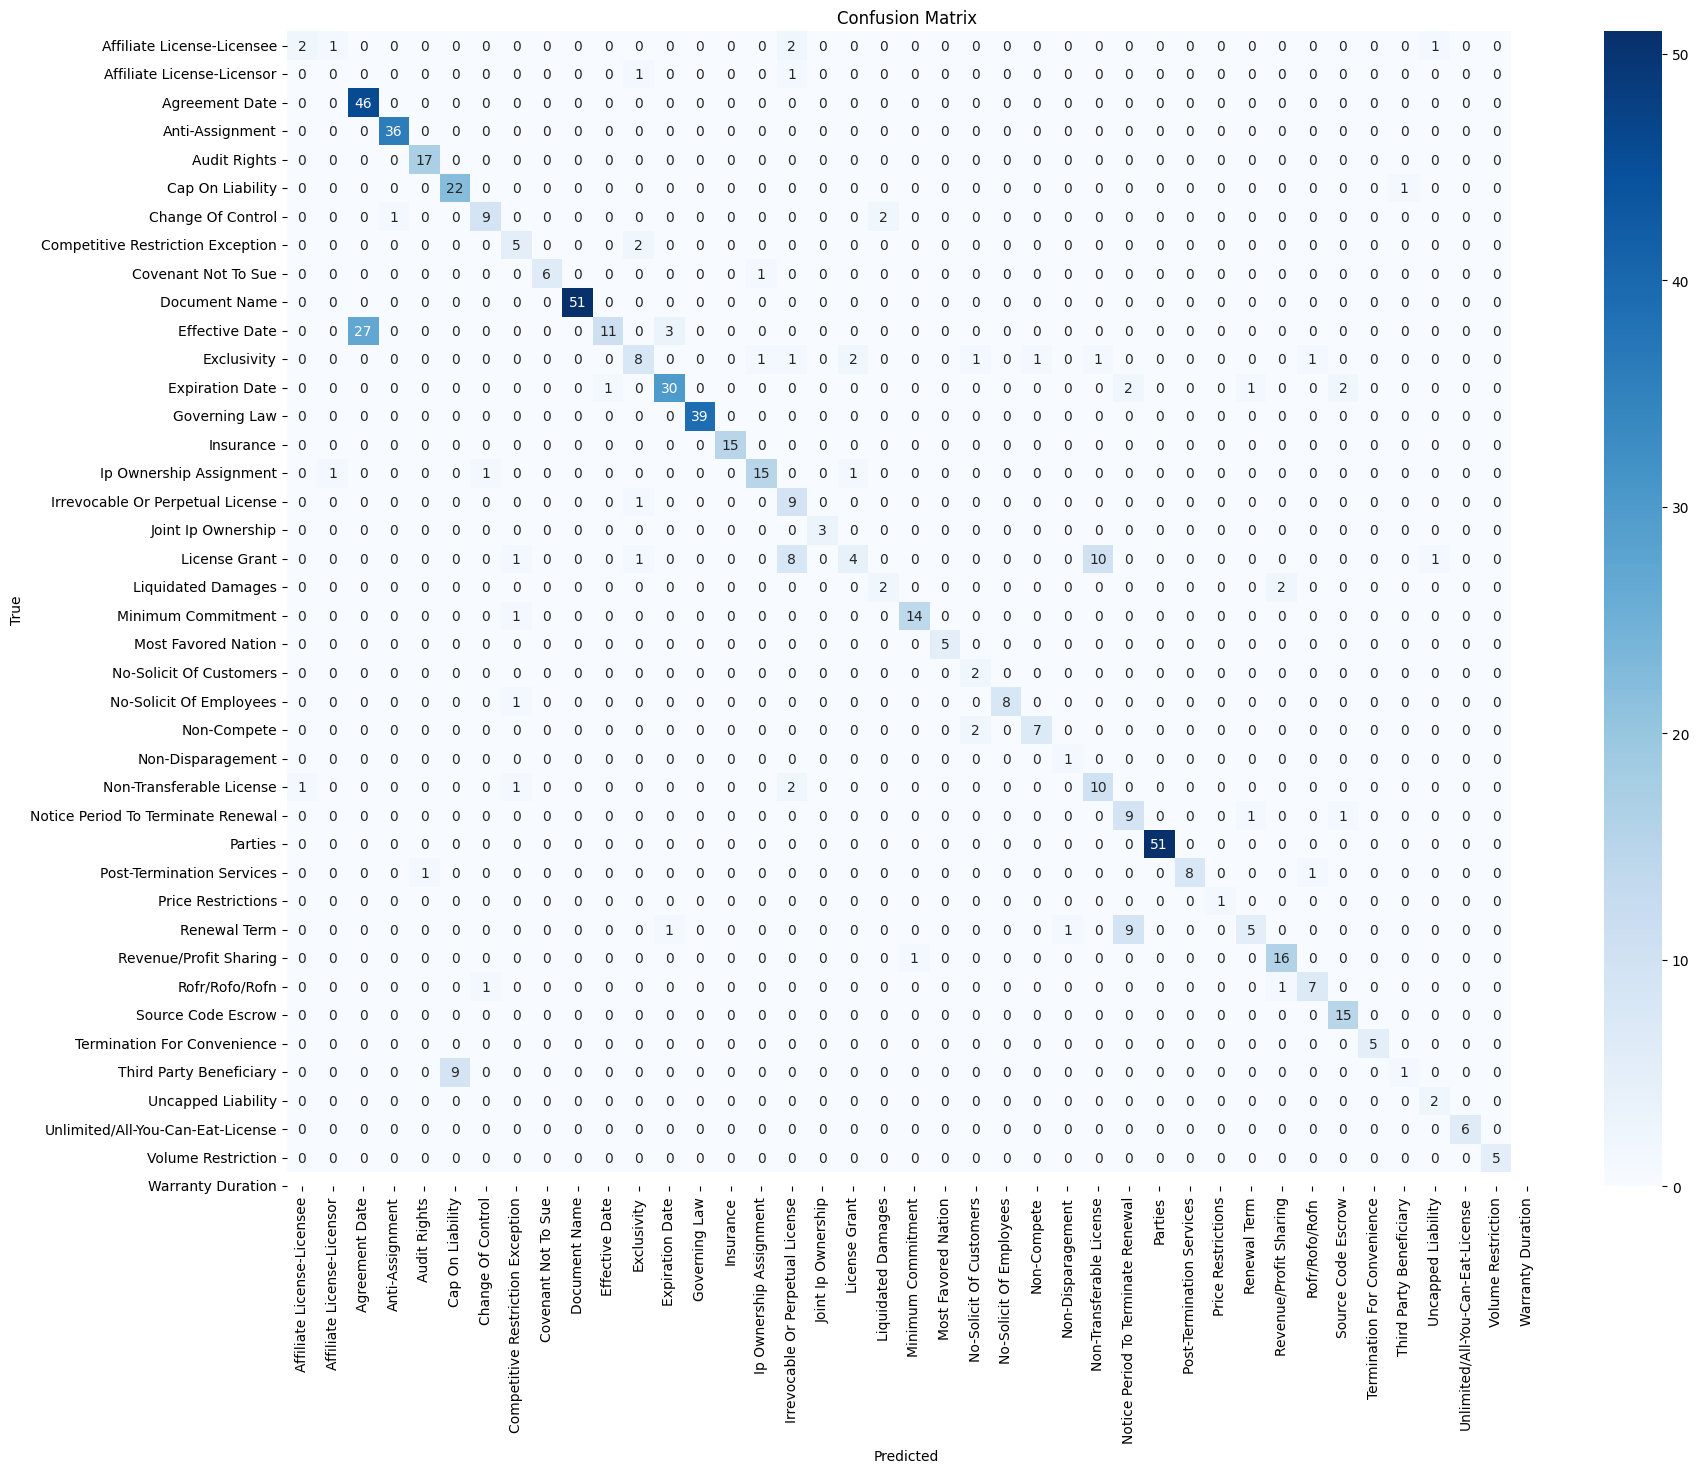

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Professional Evaluation Summary

### 1. Accuracy vs Nuance
The model achieves high accuracy on labels with distinct vocabularies (e.g., `Termination`, `Liability`). However, classes with overlapping concepts (e.g., `Payment Terms` vs `Liquidated Damages`) show some confusion, as analyzed in the previous notebook.

### 2. Error Analysis: Multi-Intent Clauses
Many "errors" are actually due to the single-label constraint on multi-intent clauses. When a clause mentions both a deadline (Payment) and a penalty (Damages), the model's prediction depends on which feature weights are dominant in the BERT backbone.

### 3. Recommendation for Phase 3
To reach production-grade reliability, we should move toward a **Hybrid Inference Pipeline**:
1. **Segmentation**: Break long clauses into atomic sentences.
2. **Multi-Label Classification**: Allow the model to flag a single segment with multiple relevant legal tags.
3. **Reasoning Layer**: Use the confidence scores to flag low-certainty predictions for manual review.


# Model Performance Analysis

The transformer-based model achieves an overall **accuracy of 81%** and a **macro F1-score of approximately 0.73**, outperforming the classical SVM baseline.

-  **Exceptional Performance**: The model performs exceptionally well on well-defined clause categories such as `Governing Law`, `Document Name`, and `Termination` clauses, achieving near-perfect scores.
-  **Performance Degradation**: Performance degrades for underrepresented classes and semantically similar categories such as `License Grant` and `Uncapped Liability`. This is primarily due to class imbalance and subtle differences in legal language.
-  **Semantic Bias**: The model shows a tendency to prioritize dominant semantic signals in multi-intent clauses, which can lead to misclassification.

##  Limitations
- **Class imbalance** significantly affects performance on rare categories.
- **Subtle Distinctions**: Difficulty distinguishing closely related legal clauses.
- **Single-label constraint**: Single-label classification limits handling of multi-intent clauses.

##  Phase 3 Connection
These limitations highlight the need for **clause segmentation** and **hybrid reasoning approaches**, which will be the primary focus of **Phase 3**. We will transition from a single-label sentence classifier to a system capable of identifying and tagging overlapping legal concepts within decomposed segments.
